In [28]:
# Analisis explotario de SIMCE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rutasimce = r"https://raw.githubusercontent.com/vcanalesg/dcc_taller_proyecto_g4/main/datos/simce2m2024_rbd_preliminar.parquet"
rutaidps  = r"https://raw.githubusercontent.com/vcanalesg/dcc_taller_proyecto_g4/main/datos/idps2M2024_rbd_preliminar.parquet"

simce = pd.read_parquet(rutasimce)
idps  = pd.read_parquet(rutaidps)


In [29]:
print(f'Simce: {simce.shape}')
print(f'idps: {idps.shape}\n')

Simce: (3000, 42)
idps: (12000, 22)



In [30]:
columnas_sel = [
    "rbd", "nom_rbd", "cod_reg_rbd", "nom_reg_rbd", "cod_com_rbd", "nom_com_rbd",
    "cod_depe2", "cod_grupo", "cod_rural_rbd", "nalu_mate2m_rbd", "prom_mate2m_rbd",
    "noaplica", "marca_mate2m_rbd"
]
# marca_mate2m_rbd
base_simce = simce[columnas_sel].copy()

base_simce.head()

,rbd,nom_rbd,cod_reg_rbd,nom_reg_rbd,cod_com_rbd,nom_com_rbd,cod_depe2,cod_grupo,cod_rural_rbd,nalu_mate2m_rbd,prom_mate2m_rbd,noaplica,marca_mate2m_rbd
0,7826,COLEGIO SAN MIGUEL,10,DE LOS LAGOS,10102,CALBUCO,2,3.0,1,106,240.0,0,NaN
1,6830,COLEGIO NUESTRA SENORA DEL CARMEN,14,DE LOS RÍOS,14101,VALDIVIA,2,3.0,1,78,240.0,0,NaN
2,40126,COLEGIO RAUL SILVA HENRIQUEZ,4,DE COQUIMBO,4301,OVALLE,1,1.0,1,67,233.0,0,NaN
3,18237,COLEGIO AMANECER SAN CARLOS,8,DEL BIOBÍO,8108,SAN PEDRO DE LA PAZ,2,4.0,1,84,267.0,0,NaN
4,14324,COLEGIO WILLIAM JAMES,5,DE VALPARAÍSO,5109,VIÑA DEL MAR,3,5.0,1,11,261.0,0,NaN


In [31]:
map_gse   = {1: "Bajo", 2: "Medio bajo", 3: "Medio", 4: "Medio alto", 5: "Alto"}
map_depe2 = {1: "Municipal", 2: "Part. subvencionado", 3: "Part. pagado", 4: "SLEP"}
map_rural = {1: "Urbano", 2: "Rural"}

base_simce["gse"] = base_simce["cod_grupo"].map(map_gse)
base_simce["depe"] = base_simce["cod_depe2"].map(map_depe2)
base_simce["zona"] = base_simce["cod_rural_rbd"].map(map_rural)

print(base_simce.shape)
base_simce.head()

(3000, 16)


,rbd,nom_rbd,cod_reg_rbd,nom_reg_rbd,cod_com_rbd,nom_com_rbd,cod_depe2,cod_grupo,cod_rural_rbd,nalu_mate2m_rbd,prom_mate2m_rbd,noaplica,marca_mate2m_rbd,gse,depe,zona
0,7826,COLEGIO SAN MIGUEL,10,DE LOS LAGOS,10102,CALBUCO,2,3.0,1,106,240.0,0,NaN,Medio,Part. subvencionado,Urbano
1,6830,COLEGIO NUESTRA SENORA DEL CARMEN,14,DE LOS RÍOS,14101,VALDIVIA,2,3.0,1,78,240.0,0,NaN,Medio,Part. subvencionado,Urbano
2,40126,COLEGIO RAUL SILVA HENRIQUEZ,4,DE COQUIMBO,4301,OVALLE,1,1.0,1,67,233.0,0,NaN,Bajo,Municipal,Urbano
3,18237,COLEGIO AMANECER SAN CARLOS,8,DEL BIOBÍO,8108,SAN PEDRO DE LA PAZ,2,4.0,1,84,267.0,0,NaN,Medio alto,Part. subvencionado,Urbano
4,14324,COLEGIO WILLIAM JAMES,5,DE VALPARAÍSO,5109,VIÑA DEL MAR,3,5.0,1,11,261.0,0,NaN,Alto,Part. pagado,Urbano


In [32]:
na = base_simce.isna().sum()
na[na > 0].sort_values(ascending=False)

marca_mate2m_rbd    2903
prom_mate2m_rbd        6
cod_grupo              5
gse                    5
dtype: int64

## Manejo de valores nulos
Debido a la baja cantidad de observaciones en valores nulos en columnas **'prom_mate2m_rbd', 'cod_grupo' y 'gse'**, se determina eliminar estos registros de la base a trabajar. En relacion a la columna **'marca_mate2m_rbd'** se tiene 2903 registros nulos...(falta chachara)

In [33]:
base_simce = base_simce.dropna(subset=["cod_grupo"]).copy()
base_simce = base_simce.dropna(subset=["prom_mate2m_rbd"]).copy()
base_simce = base_simce.dropna(subset=["gse"]).copy()

base_simce.shape

(2994, 16)

## Seleccion de GSE a estudiar

In [34]:
mask = base_simce["gse"].isin(['Bajo', 'Medio bajo'])
base_simce[mask].pivot_table(
    index="gse",
    values="rbd",
    aggfunc="nunique",
    margins=True,
    margins_name="Total"
)

,rbd
gse,
Bajo,693
Medio bajo,867
Total,1560


In [35]:
sub_bs = base_simce[mask].copy()

c1, c2 = 252, 319
cortes    = [-np.inf, c1, c2, np.inf]
etiquetas = ["Insuficiente", "Elemental", "Adecuado"]

sub_bs["nivel"] = pd.cut(sub_bs["prom_mate2m_rbd"], bins=cortes,
                      labels=etiquetas, right=False)

sub_bs.groupby("nivel", observed=False)["rbd"].count()

nivel
Insuficiente    1186
Elemental        357
Adecuado          17
Name: rbd, dtype: int64

## Decisión de target

 En el resultado de la inspeccion anterior, indica que 1186 son insuficiente, 357 elemental y apenas 17 adecuado. Con tres clases así, ningún modelo va a aprender la clase "adecuado". Por lo tanto, se toma la decisión de transformar las clases objetivo a target binario entre **"Insuficiente" y "Elemental o adecuado"**

In [36]:
sub_bs["target_bin_cat"] = np.where(sub_bs["nivel"] == "Insuficiente", "Insuficiente", "Elemental o adecuado")
sub_bs["target_bin"] = (sub_bs["target_bin_cat"] == "Elemental o adecuado").astype(int)
print(sub_bs["target_bin_cat"].value_counts())
print()
print(sub_bs["target_bin"].value_counts())

target_bin_cat
Insuficiente            1186
Elemental o adecuado     374
Name: count, dtype: int64

target_bin
0    1186
1     374
Name: count, dtype: int64


In [37]:
na_idps = idps.isna().sum()
na_idps[na_idps > 0].sort_values(ascending=False)

dif          1115
sigdif       1115
sigdifgru     105
difgru        105
prom           45
cod_grupo      20
dtype: int64

In [38]:
map_ind = {
    "AM": "autoestima_motiv",
    "CC": "convivencia",
    "PF": "participacion",
    "HV": "vida_saludable",
}

idps["prom"] = pd.to_numeric(idps["prom"], errors="coerce")

idps_ancho = (idps
             .pivot_table(index="rbd", columns="ind", values="prom")
             .rename(columns=map_ind)
             .reset_index())
idps_ancho.columns.name = None

print("idps_wide:", idps_ancho.shape)
idps_ancho.head(3)

idps_wide: (2992, 5)


,rbd,autoestima_motiv,convivencia,vida_saludable,participacion
0,1,74.0,75.0,74.0,79.0
1,4,74.0,74.0,70.0,75.0
2,5,71.0,73.0,71.0,75.0


In [39]:
base = sub_bs.merge(idps_ancho, on="rbd", how="left")

na_base = base.isna().sum()
print(na_base[na_base > 0].sort_values())
print()
print(base.shape)

convivencia            7
marca_mate2m_rbd    1497
dtype: int64

(1560, 23)


In [40]:
base = base.dropna(subset=['convivencia']).copy()
print(base.shape)

(1553, 23)


## Distribución del puntaje y del target

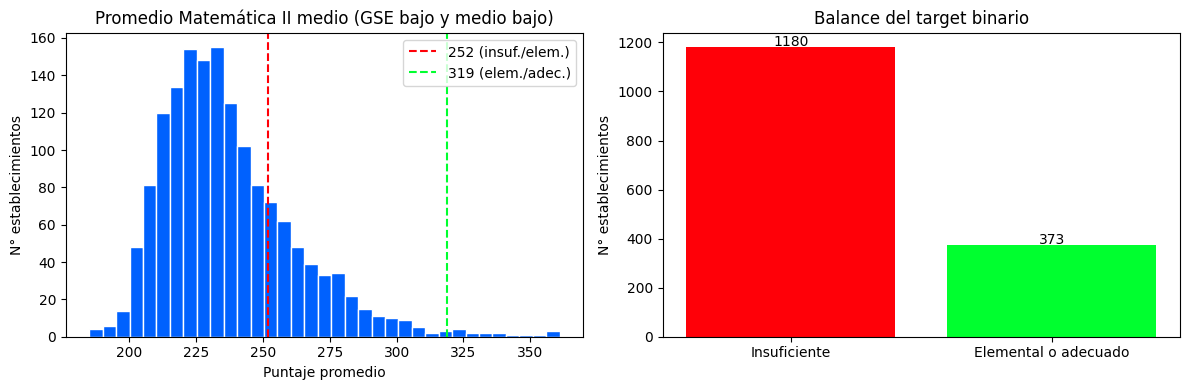

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(base["prom_mate2m_rbd"], bins=35, color="#0061FE", edgecolor="white")
axes[0].axvline(252, color="#FF0008", ls="--", lw=1.5, label="252 (insuf./elem.)")
axes[0].axvline(319, color="#00FF2F", ls="--", lw=1.5, label="319 (elem./adec.)")
axes[0].set_title("Promedio Matemática II medio (GSE bajo y medio bajo)")
axes[0].set_xlabel("Puntaje promedio"); axes[0].set_ylabel("N° establecimientos")
axes[0].legend()

orden = ["Insuficiente", "Elemental o adecuado"]
conteo = base["target_bin_cat"].value_counts().reindex(orden)
axes[1].bar(orden, conteo.values, color=["#FF0008", "#00FF2F"])
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 5, str(v), ha="center")
axes[1].set_title("Balance del target binario")
axes[1].set_ylabel("N° establecimientos")

plt.tight_layout(); plt.show()

## Distribución de los indicadores IDPS

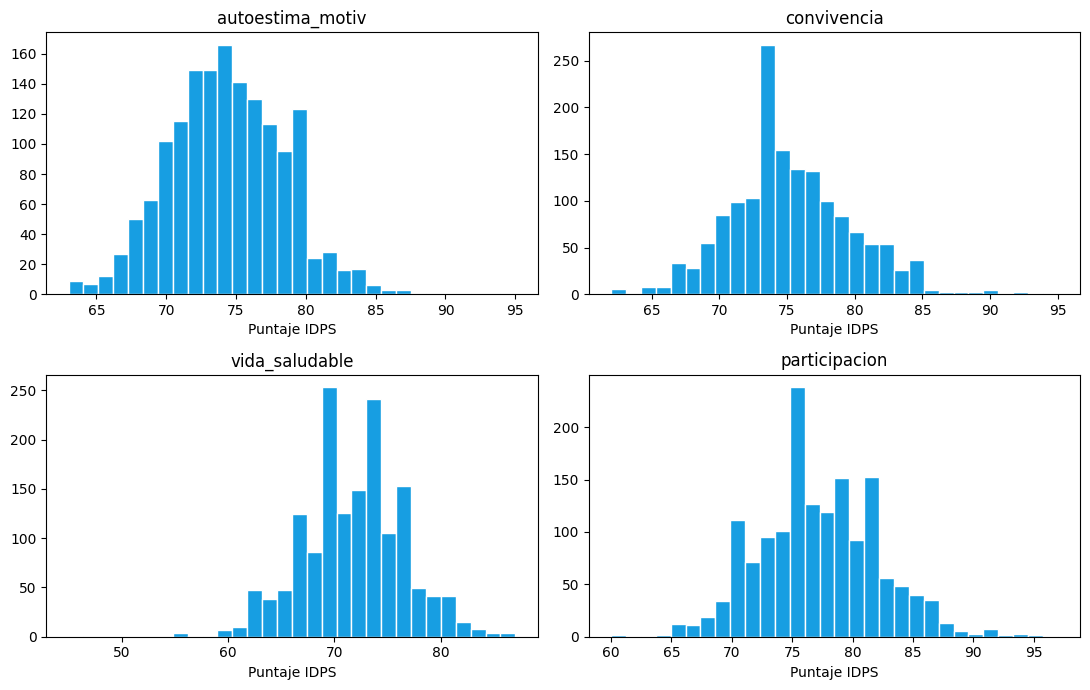

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ['autoestima_motiv', 'convivencia', 'vida_saludable', 'participacion']):
    ax.hist(base[col].dropna(), bins=30, color="#179EE2", edgecolor="white")
    ax.set_title(col); ax.set_xlabel("Puntaje IDPS")
#plt.suptitle("Distribución de los indicadores IDPS", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

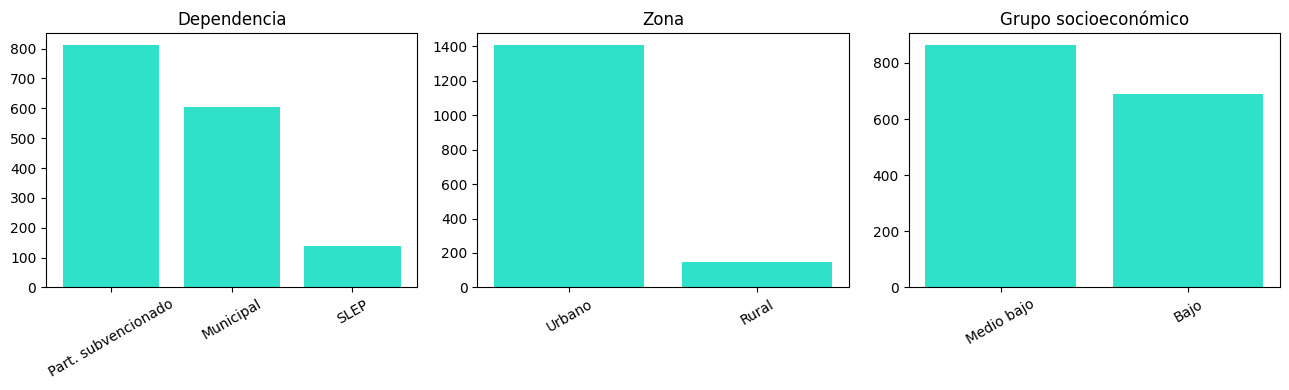

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, titulo in zip(axes,
                           ["depe", "zona", "gse"],
                           ["Dependencia", "Zona", "Grupo socioeconómico"]):
    vc = base[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color="#30E1C9")
    ax.set_title(titulo); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Indicadores IDPS según desempeño en Matemática

## Correlacion de Pearson

In [44]:
base[['autoestima_motiv','convivencia','vida_saludable','participacion','target_bin']].corr('pearson')['target_bin']

autoestima_motiv    0.289576
convivencia         0.311171
vida_saludable      0.203649
participacion       0.277286
target_bin          1.000000
Name: target_bin, dtype: float64

Correlaciones entre 0.2 y 0.35 son débiles-moderadas. Ninguna variable es muy fuerte por sí sola, pero todas apuntan en la dirección correcta (positiva: más IDPS → más probabilidad de ser "Elemental o adecuado").

In [45]:
from sklearn.metrics import roc_auc_score
for col in ['autoestima_motiv', 'convivencia', 'vida_saludable', 'participacion']:
    auc = roc_auc_score(base['target_bin'], base[col].fillna(base[col].median()))
    print(f"{col}: AUC={auc:.3f}")


autoestima_motiv: AUC=0.687
convivencia: AUC=0.707
vida_saludable: AUC=0.637
participacion: AUC=0.682


AUC de 0.5 = no discrimina nada, 1.0 = discrimina perfecto. Los valores entre 0.63 y 0.71 indican capacidad predictiva moderada.

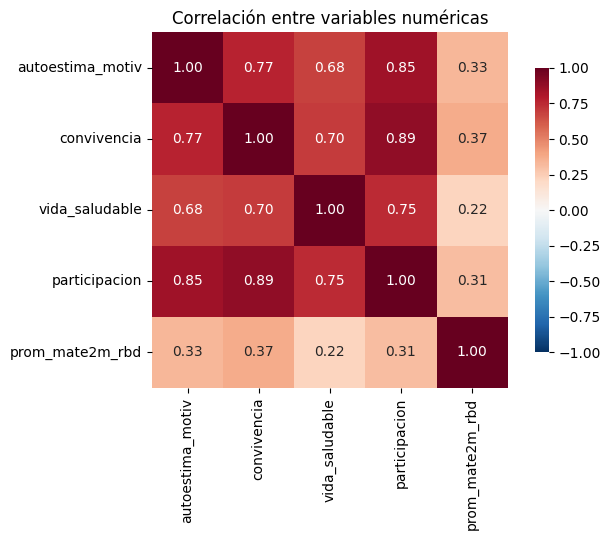

In [46]:
num = base[['autoestima_motiv', 'convivencia', 'vida_saludable', 'participacion', 'prom_mate2m_rbd']]
corr = num.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout(); plt.show()

### **Conclusion**
El indicador más útil para predecir es **convivencia** (mejor AUC y correlación), seguido de autoestima_motiv. vida_saludable